# 1. Import libraries and read benchmark data

This section imports the Python libraries required for data processing and visualization and loads the benchmark results generated by **LitModDyn**. The dataset contains the spatial coordinates, density, viscosity, and velocity components at each computational grid point. The corresponding **ASPECT** results can also be loaded for comparison by uncommenting the relevant line.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('LitModDyn_viscosity1_density11.txt', sep='\t')
# df = pd.read_csv('ASPECT_viscosity1_density11.txt', sep='\t')
print(df.head())

      MX     MY  MRHO  META       MVX       MVY
0  0.002  0.002     1     1  0.000005 -0.000005
1  0.002  0.006     1     1  0.000014 -0.000014
2  0.002  0.010     1     1  0.000023 -0.000023
3  0.002  0.014     1     1  0.000016 -0.000032
4  0.002  0.018     1     1  0.000010 -0.000041


In [2]:
x = df['MX'].values
y = df['MY'].values

nx = len(np.unique(x))
ny = len(np.unique(y))

print(nx, ny)
X    = x.reshape(ny, nx)
Y    = y.reshape(ny, nx)

MRHO = df['MRHO'].values.reshape(ny, nx)
MVX  = df['MVX'].values.reshape(ny, nx)
MVY  = df['MVY'].values.reshape(ny, nx)

250 250


## 2. Visualization of density and velocity fields

This section visualizes the density distribution and velocity fields obtained from the LitModDyn benchmark simulation.

The density field is displayed as a colored scalar field, while the horizontal and vertical velocity components are shown together with velocity vectors. The velocity vectors illustrate both the magnitude and direction of the flow field generated by the sinking dense block.

**Panels:**

- Density field (ρ)
- Horizontal velocity field (Vₓ)
- Vertical velocity field (Vᵧ)


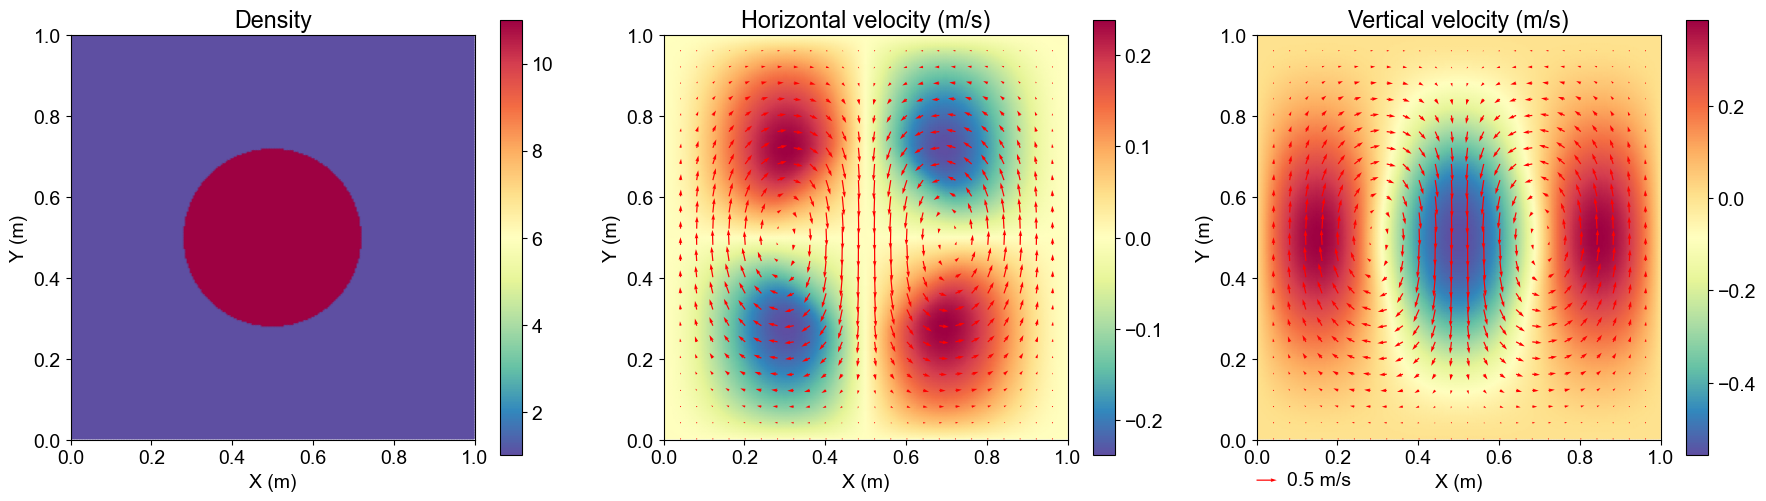

In [3]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 14
speed = np.sqrt(MVX**2 + MVY**2)

step = 10

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# MRHO
pcm0 = axes[0].pcolormesh(
    X, Y, MRHO,
    shading='gouraud',
    cmap='Spectral_r'
)
axes[0].set_title('Density')
axes[0].set_aspect('equal')
plt.colorbar(pcm0, ax=axes[0])

# MVX + velocity vectors
pcm1 = axes[1].pcolormesh(
    X, Y, MVX,
    shading='gouraud',
    cmap='Spectral_r'
)
axes[1].quiver(
    X[::step, ::step],
    Y[::step, ::step],
    MVX[::step, ::step],
    MVY[::step, ::step],
    color='red',
    scale=10,
    width=0.003
)
axes[1].set_title('Horizontal velocity (m/s)')
axes[1].set_aspect('equal')
plt.colorbar(pcm1, ax=axes[1])

# MVY + velocity vectors
pcm2 = axes[2].pcolormesh(
    X, Y, MVY,
    shading='gouraud',
    cmap='Spectral_r'
)
q = axes[2].quiver(
    X[::step, ::step],
    Y[::step, ::step],
    MVX[::step, ::step],
    MVY[::step, ::step],
    color='red',
    scale=10,
    width=0.003
)
axes[2].set_title('Vertical velocity (m/s)')
axes[2].set_aspect('equal')
plt.colorbar(pcm2, ax=axes[2])

# 箭头大小图例
axes[2].quiverkey(
    q,
    X=0.05,
    Y=-0.10,
#     U=np.max(speed), 
    U=0.5,
    label='0.5 m/s',
    labelpos='E',
    coordinates='axes'
)


for ax in axes:
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
plt.tight_layout()
plt.show()

In [4]:
import pandas as pd
import numpy as np

# 读取两个结果
df1 = pd.read_csv('ASPECT_viscosity1_density11.txt', sep='\t')
df2 = pd.read_csv('LitModDyn_viscosity1_density11.txt', sep='\t')

# 差值
dMVX = df1['MVX'].values - df2['MVX'].values
dMVY = df1['MVY'].values - df2['MVY'].values

# 网格尺寸
nx = len(np.unique(df1['MX']))
ny = len(np.unique(df1['MY']))

# 重构二维场
X = df1['MX'].values.reshape(ny, nx)
Y = df1['MY'].values.reshape(ny, nx)

dMVX = dMVX.reshape(ny, nx)
dMVY = dMVY.reshape(ny, nx)

print('dMVX max =', np.max(np.abs(dMVX)))
print('dMVY max =', np.max(np.abs(dMVY)))

dMVX max = 8.021361352916756e-15
dMVY max = 2.6922908347160046e-15


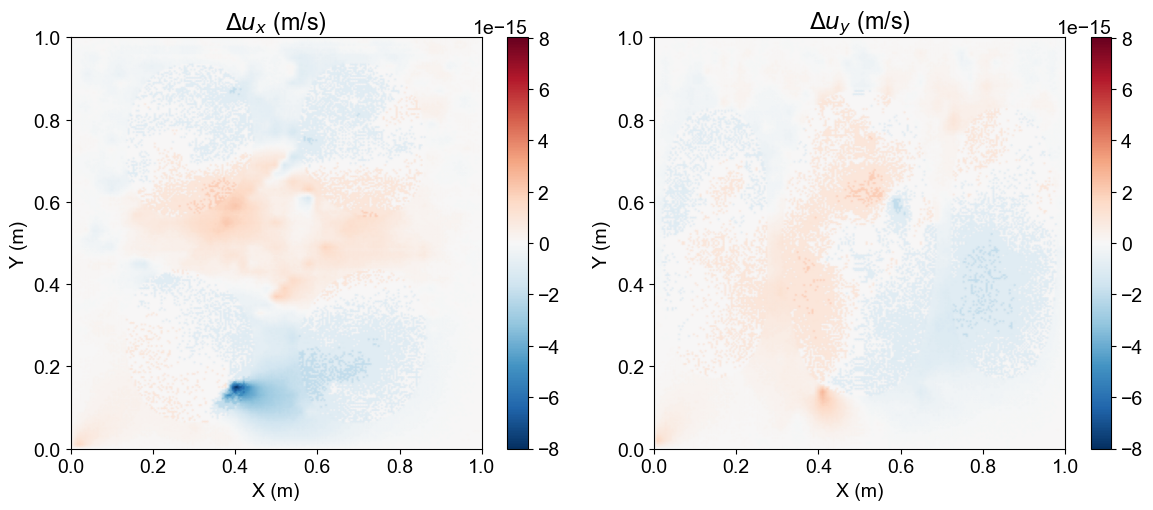

In [5]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 14

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 使用相同色标范围
vmax = np.max(np.abs([dMVX, dMVY]))
vmin = -vmax

pcm1 = axes[0].pcolormesh(
    X, Y, dMVX,
    shading='gouraud',
    cmap='RdBu_r',
    vmin=vmin,
    vmax=vmax
)

axes[0].set_title(r'$\Delta u_x$ (m/s)')
axes[0].set_xlim(0,1)
axes[0].set_ylim(0,1)
axes[0].set_aspect('equal')
plt.colorbar(pcm1, ax=axes[0])

pcm2 = axes[1].pcolormesh(
    X, Y, dMVY,
    shading='gouraud',
    cmap='RdBu_r',
    vmin=vmin,
    vmax=vmax
)

axes[1].set_title(r'$\Delta u_y$ (m/s)')
axes[1].set_xlim(0,1)
axes[1].set_ylim(0,1)
axes[1].set_aspect('equal')
plt.colorbar(pcm2, ax=axes[1])

for ax in axes:
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')

plt.tight_layout()
plt.show()

## 3. Comparison between LitModDyn and ASPECT benchmark solutions

This section compares the benchmark results obtained from LitModDyn with the reference solution calculated by ASPECT for the falling-block experiment.

The first row presents the model setup and the velocity fields predicted by LitModDyn. The second row shows the differences between the LitModDyn and ASPECT solutions, allowing a quantitative assessment of the agreement between the two numerical approaches.

### Figure contents

**(a)** Model setup and initial density configuration.

**(b)** Horizontal velocity field ($V_x$) calculated by LitModDyn.

**(c)** Vertical velocity field ($V_y$) calculated by LitModDyn.

**(d)** Difference in horizontal velocity between LitModDyn and ASPECT
($V_x^{\mathrm{LitModDyn}} - V_x^{\mathrm{ASPECT}}$).

**(e)** Difference in vertical velocity between LitModDyn and ASPECT
($V_y^{\mathrm{LitModDyn}} - V_y^{\mathrm{ASPECT}}$).

Velocity vectors are superimposed on the LitModDyn velocity fields to illustrate the direction and magnitude of the flow induced by the sinking dense block.

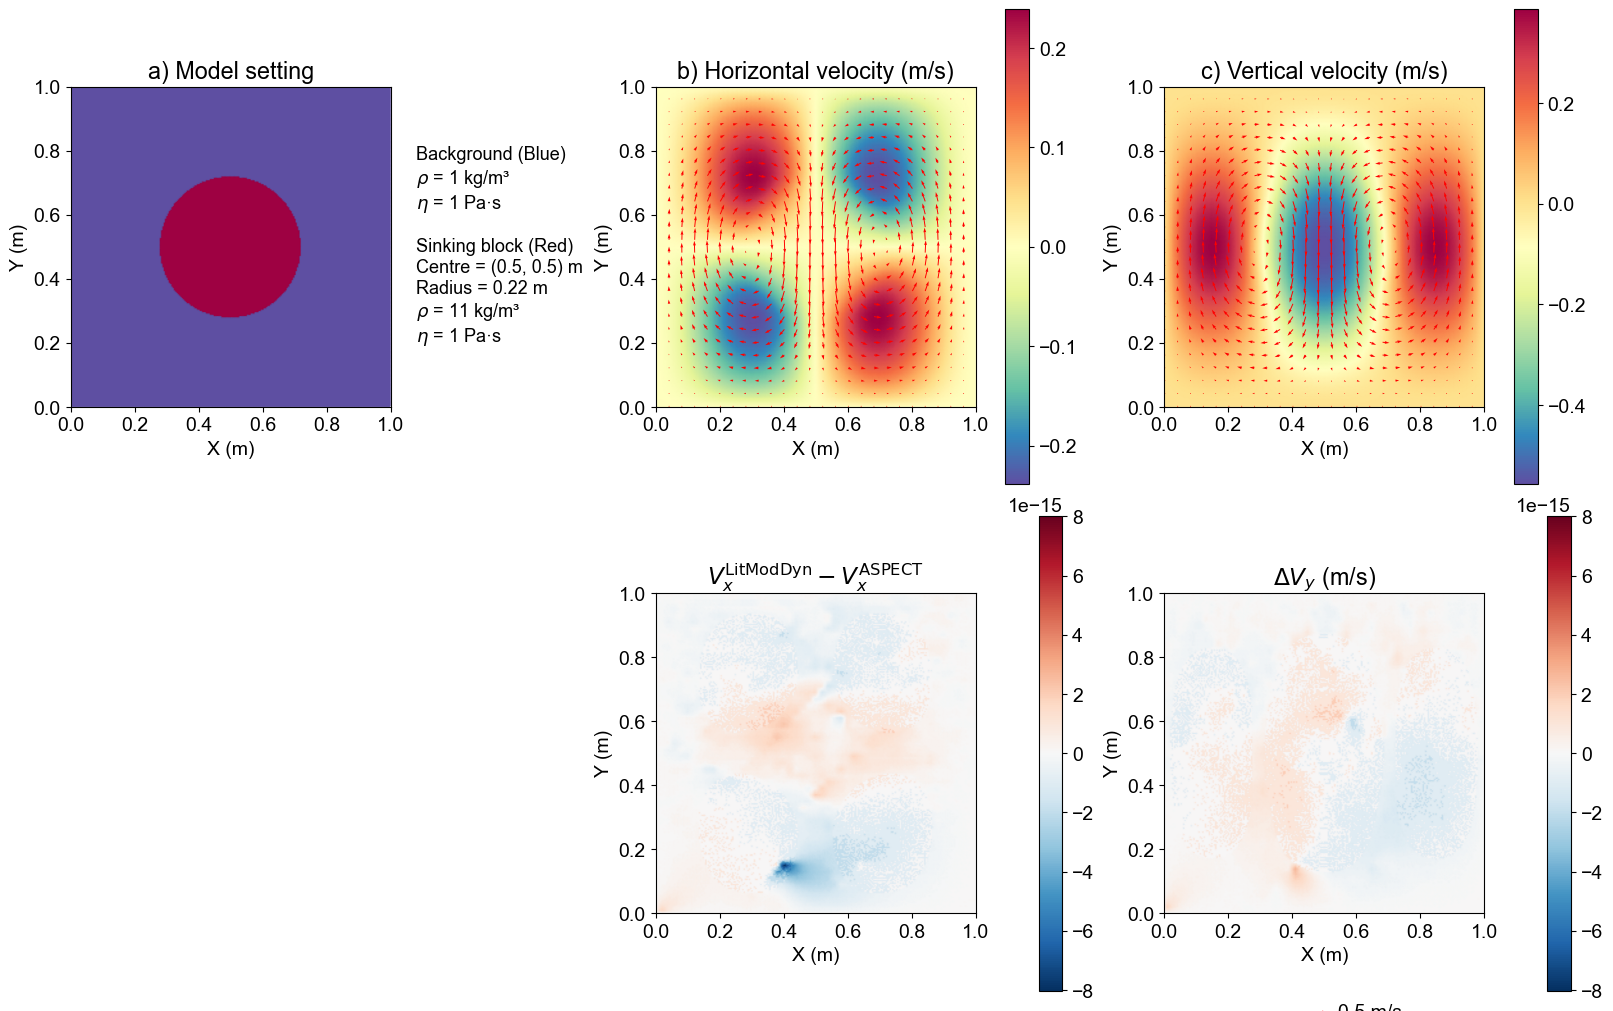

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================
# Plot settings
# =====================================
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 14

speed = np.sqrt(MVX**2 + MVY**2)

step = 10

# =====================================
# Figure
# =====================================
fig, axes = plt.subplots(
    2, 3,
    figsize=(16, 10),
    constrained_layout=True
)

# =====================================
# Density
# =====================================
pcm0 = axes[0,0].pcolormesh(
    X, Y, MRHO,
    shading='gouraud',
    cmap='Spectral_r'
)

axes[0,0].set_title('a) Model setting')
# plt.colorbar(pcm0, ax=axes[0,0])

# 添加说明文字
info_text = (
#     'Box: 1 × 1 m²\n'
#     'R = 0.22 m\n'
#     'Center = (0.5, 0.5) m\n\n'
    r'Background (Blue)' '\n'
    r'$\rho$ = 1 kg/m³' '\n'
    r'$\eta$ = 1 Pa·s' '\n\n'
    r'Sinking block (Red)' '\n'
    r'Centre = (0.5, 0.5) m' '\n'
    r'Radius = 0.22 m' '\n'
    r'$\rho$ = 11 kg/m³' '\n'
    r'$\eta$ = 1 Pa·s'
)

axes[0,0].text(
    1.08, 0.5,          # 位置：x>1 表示放在图右侧
    info_text,
    transform=axes[0,0].transAxes,
    fontsize=13,
    va='center',
    ha='left',
    bbox=dict(
        boxstyle='round',
        facecolor='white',
        alpha=0.75,
        edgecolor='none'
    )
)
# =====================================
# Horizontal velocity
# =====================================
pcm1 = axes[0,1].pcolormesh(
    X, Y, MVX,
    shading='gouraud',
    cmap='Spectral_r'
)

axes[0,1].quiver(
    X[::step, ::step],
    Y[::step, ::step],
    MVX[::step, ::step],
    MVY[::step, ::step],
    color='red',
    scale=10,
    width=0.003
)

axes[0,1].set_title('b) Horizontal velocity (m/s)')
plt.colorbar(pcm1, ax=axes[0,1])

# =====================================
# Vertical velocity
# =====================================
pcm2 = axes[0,2].pcolormesh(
    X, Y, MVY,
    shading='gouraud',
    cmap='Spectral_r'
)

axes[0,2].quiver(
    X[::step, ::step],
    Y[::step, ::step],
    MVX[::step, ::step],
    MVY[::step, ::step],
    color='red',
    scale=10,
    width=0.003
)

axes[0,2].set_title('c) Vertical velocity (m/s)')
plt.colorbar(pcm2, ax=axes[0,2])

# =====================================
# Error range
# =====================================
errmax = max(
    np.max(np.abs(dMVX)),
    np.max(np.abs(dMVY))
)

# =====================================
# dMVX
# =====================================
pcm3 = axes[1,1].pcolormesh(
    X, Y, dMVX,
    shading='gouraud',
    cmap='RdBu_r',
    vmin=-errmax,
    vmax= errmax
)

axes[1,1].set_title(r'$V_x^{\mathrm{LitModDyn}} - V_x^{\mathrm{ASPECT}}$')
plt.colorbar(pcm3, ax=axes[1,1])

# =====================================
# dMVY
# =====================================
pcm4 = axes[1,2].pcolormesh(
    X, Y, dMVY,
    shading='gouraud',
    cmap='RdBu_r',
    vmin=-errmax,
    vmax= errmax
)

axes[1,2].set_title(r'$\Delta V_y$ (m/s)')
plt.colorbar(pcm4, ax=axes[1,2])

# =====================================
# Velocity magnitude + vectors
# =====================================
axes[1,0].remove()

# =====================================
# Velocity scale arrow
# =====================================
axes[1,2].quiverkey(
    q,
    X=0.15,
    Y=-0.15,
    U=0.5,
    label='0.5 m/s',
    labelpos='E',
    coordinates='axes'
)

# =====================================
# Common formatting
# =====================================
for ax in axes.flat:

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.set_aspect('equal')

    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')

plt.show()

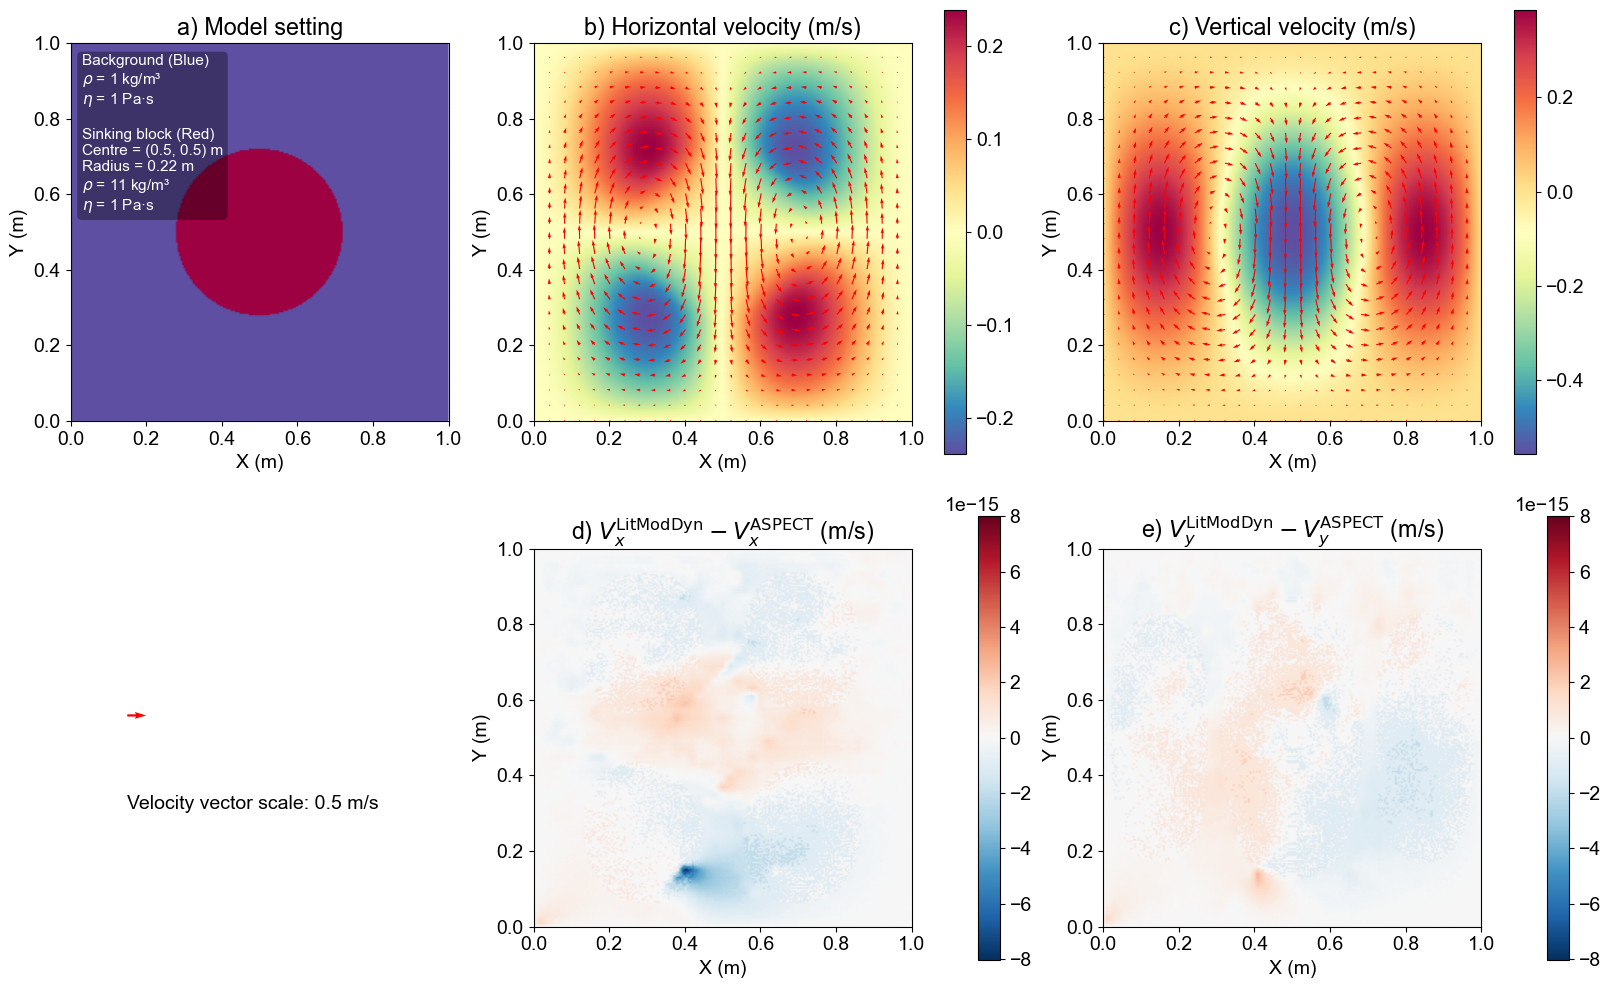

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================
# Plot settings
# =====================================
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 14

speed = np.sqrt(MVX**2 + MVY**2)
step = 10

# =====================================
# Figure
# =====================================
fig, axes = plt.subplots(
    2, 3,
    figsize=(16, 10),
    constrained_layout=True
)

# =====================================
# a) Model setting
# =====================================
pcm0 = axes[0, 0].pcolormesh(
    X, Y, MRHO,
    shading='gouraud',
    cmap='Spectral_r'
)

axes[0, 0].set_title('a) Model setting')

info_text = (
    r'Background (Blue)' '\n'
    r'$\rho$ = 1 kg/m³' '\n'
    r'$\eta$ = 1 Pa·s' '\n\n'
    r'Sinking block (Red)' '\n'
    r'Centre = (0.5, 0.5) m' '\n'
    r'Radius = 0.22 m' '\n'
    r'$\rho$ = 11 kg/m³' '\n'
    r'$\eta$ = 1 Pa·s'
)

axes[0, 0].text(
    0.03, 0.97,
    info_text,
    transform=axes[0, 0].transAxes,
    fontsize=11,
    va='top',
    ha='left',
    color='white',
    bbox=dict(
        boxstyle='round',
        facecolor='black',
        alpha=0.35,
        edgecolor='none'
    )
)

# =====================================
# b) Horizontal velocity
# =====================================
pcm1 = axes[0, 1].pcolormesh(
    X, Y, MVX,
    shading='gouraud',
    cmap='Spectral_r'
)

q1 = axes[0, 1].quiver(
    X[::step, ::step],
    Y[::step, ::step],
    MVX[::step, ::step],
    MVY[::step, ::step],
    color='red',
    scale=10,
    width=0.003
)

axes[0, 1].set_title('b) Horizontal velocity (m/s)')
plt.colorbar(pcm1, ax=axes[0, 1])

# =====================================
# c) Vertical velocity
# =====================================
pcm2 = axes[0, 2].pcolormesh(
    X, Y, MVY,
    shading='gouraud',
    cmap='Spectral_r'
)

q2 = axes[0, 2].quiver(
    X[::step, ::step],
    Y[::step, ::step],
    MVX[::step, ::step],
    MVY[::step, ::step],
    color='red',
    scale=10,
    width=0.003
)

axes[0, 2].set_title('c) Vertical velocity (m/s)')
plt.colorbar(pcm2, ax=axes[0, 2])

# =====================================
# Error range
# =====================================
errmax = max(
    np.max(np.abs(dMVX)),
    np.max(np.abs(dMVY))
)

# =====================================
# d) Difference in Vx
# =====================================
pcm3 = axes[1, 1].pcolormesh(
    X, Y, dMVX,
    shading='gouraud',
    cmap='RdBu_r',
    vmin=-errmax,
    vmax=errmax
)

axes[1, 1].set_title(
    r'd) $V_x^{\mathrm{LitModDyn}} - V_x^{\mathrm{ASPECT}}$ (m/s)'
)
plt.colorbar(pcm3, ax=axes[1, 1])

# =====================================
# e) Difference in Vy
# =====================================
pcm4 = axes[1, 2].pcolormesh(
    X, Y, dMVY,
    shading='gouraud',
    cmap='RdBu_r',
    vmin=-errmax,
    vmax=errmax
)

axes[1, 2].set_title(
    r'e) $V_y^{\mathrm{LitModDyn}} - V_y^{\mathrm{ASPECT}}$ (m/s)'
)
plt.colorbar(pcm4, ax=axes[1, 2])

# =====================================
# Empty panel for velocity scale
# =====================================
axes[1, 0].axis('off')

axes[1, 0].quiver(
    0.15, 0.55,
    0.5, 0,
    color='red',
    scale=10,
    width=0.006,
    angles='xy',
    scale_units='xy'
)

axes[1, 0].text(
    0.15, 0.35,
    'Velocity vector scale: 0.5 m/s',
    fontsize=14,
    ha='left',
    va='center'
)

axes[1, 0].set_xlim(0, 1)
axes[1, 0].set_ylim(0, 1)

# =====================================
# Common formatting
# =====================================
for ax in [axes[0,0], axes[0,1], axes[0,2], axes[1,1], axes[1,2]]:

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')

    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')

plt.show()